In [14]:
import sys
print(sys.executable)

C:\DL\Brain-Tumor-Detection\venv\Scripts\python.exe


In [15]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image
warnings.filterwarnings("ignore")
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


In [16]:
import os
train_path = "../dataset/Training"
test_path = "../dataset/Testing"
print("Train Exists :", os.path.exists(train_path))
print("Test Exists  :", os.path.exists(test_path))
classes = sorted(os.listdir(train_path))
print(classes)
print("Training Dataset\n")
for cls in classes:
    total = len(os.listdir(os.path.join(train_path, cls)))
    print(f"{cls:<12} : {total}")

Train Exists : True
Test Exists  : True
['glioma', 'meningioma', 'notumor', 'pituitary']
Training Dataset

glioma       : 1400
meningioma   : 1400
notumor      : 1400
pituitary    : 1400


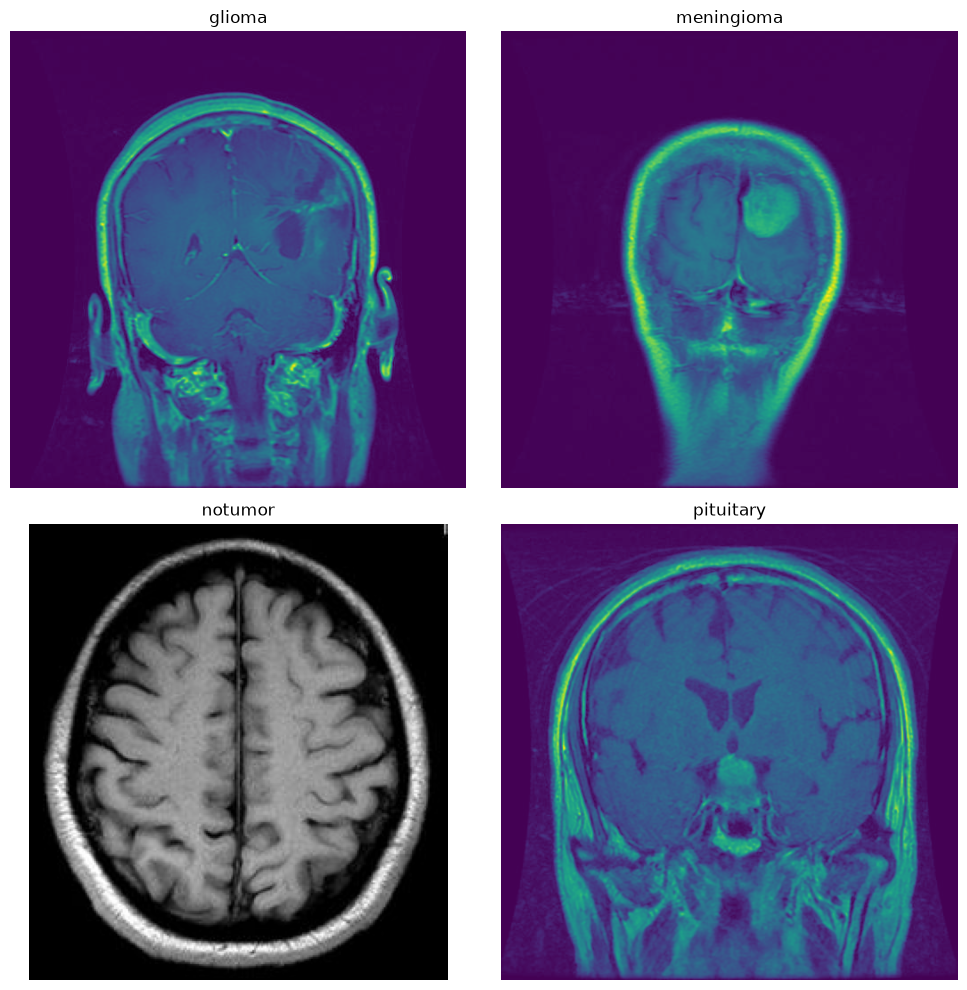

In [17]:
plt.figure(figsize=(10,10))
for i, cls in enumerate(classes):
    img_name = random.choice(os.listdir(os.path.join(train_path, cls)))
    img_path = os.path.join(train_path, cls, img_name)
    img = Image.open(img_path)
    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")
plt.tight_layout()
plt.show()

In [18]:
for cls in classes:
    img_name = random.choice(os.listdir(os.path.join(train_path, cls)))
    img = Image.open(os.path.join(train_path, cls, img_name))
    print(f"{cls:<12} -> {img.size}")

glioma       -> (512, 512)
meningioma   -> (512, 512)
notumor      -> (206, 244)
pituitary    -> (512, 512)


In [19]:
#Data Generator
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

validation_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    subset="validation",
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


In [20]:
#model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.models import Model

base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze initially
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dropout(0.4)(x)

x = Dense(256, activation="relu")(x)

x = Dropout(0.3)(x)

output = Dense(4, activation="softmax")(x)

model = Model(
    inputs=base_model.input,
    outputs=output
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling (Rescaling)         │ (None, 224, 224, 3)       │               0 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ normalization (Normalization) │ (None, 224, 224, 3)       │               7 │ rescaling[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling_1 (Rescaling)       │ (None, 224, 224, 3)       │               0 │ normalization[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv_pad (ZeroPadding2D) │ (None, 225, 225, 3)       │               0 │ rescaling_1[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv (Conv2D)            │ (None, 112, 112, 32)      │             864 │ stem_conv_pad[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_bn (BatchNormalization)  │ (None, 112, 112, 32)      │             128 │ stem_conv[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_activation (Activation)  │ (None, 112, 112, 32)      │               0 │ stem_bn[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_dwconv                │ (None, 112, 112, 32)      │             288 │ stem_activation[0][0]      │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_bn                    │ (None, 112, 112, 32)      │             128 │ block1a_dwconv[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_activation            │ (None, 112, 112, 32)      │               0 │ block1a_bn[0][0]           │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_squeeze            │ (None, 32)                │               0 │ block1a_activation[0][0]   │
│ (GlobalAveragePooling2D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_reshape (Reshape)  │ (None, 1, 1, 32)          │               0 │ block1a_se_squeeze[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_reduce (Conv2D)    │ (None, 1, 1, 8)           │             264 │ block1a_se_reshape[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_expand (Conv2D)    │ (None, 1, 1, 32)          │             288 │ block1a_se_reduce[0][0]    │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 4,378,535 (16.70 MB)

 Trainable params: 328,964 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [21]:
#compiler
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [22]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)
checkpoint = ModelCheckpoint(
    "../models/best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

In [23]:
import os

os.makedirs("../models", exist_ok=True)

In [25]:
callbacks = [early_stop, checkpoint, reduce_lr]
print(early_stop)
print(checkpoint)
print(reduce_lr)

In [26]:
#train stage 1
history = model.fit(

    train_generator,

    validation_data=validation_generator,

    epochs=20,

    callbacks=callbacks
)

Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 952ms/step - accuracy: 0.7513 - loss: 0.6339
Epoch 1: val_accuracy improved from None to 0.85714, saving model to ../models/best_model.keras

Epoch 1: finished saving model to ../models/best_model.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 191s 1s/step - accuracy: 0.7513 - loss: 0.6339 - val_accuracy: 0.8571 - val_loss: 0.3960 - learning_rate: 0.0010
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 921ms/step - accuracy: 0.8199 - loss: 0.4516
Epoch 2: val_accuracy improved from 0.85714 to 0.86250, saving model to ../models/best_model.keras

Epoch 2: finished saving model to ../models/best_model.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 162s 1s/step - accuracy: 0.8199 - loss: 0.4516 - val_accuracy: 0.8625 - val_loss: 0.3639 - learning_rate: 0.0010
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 927ms/step - accuracy: 0.8348 - loss: 0.4167
Epoch 3: val_accuracy improved from 0.86250 to 0.88571, saving model to ../models/best_model.keras

Epoch 3: finished saving model to

In [27]:
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False
model.compile(
    optimizer=Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [28]:
#train stage 2 after fine tunning
history_finetune = model.fit(

    train_generator,

    validation_data=validation_generator,

    epochs=10,

    callbacks=callbacks
)

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8020 - loss: 0.5062
Epoch 1: val_accuracy did not improve from 0.91518
140/140 ━━━━━━━━━━━━━━━━━━━━ 207s 1s/step - accuracy: 0.8020 - loss: 0.5062 - val_accuracy: 0.8964 - val_loss: 0.2865 - learning_rate: 1.0000e-05
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8435 - loss: 0.4226
Epoch 2: val_accuracy did not improve from 0.91518
140/140 ━━━━━━━━━━━━━━━━━━━━ 181s 1s/step - accuracy: 0.8435 - loss: 0.4226 - val_accuracy: 0.8884 - val_loss: 0.3026 - learning_rate: 1.0000e-05
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8498 - loss: 0.3775
Epoch 3: val_accuracy did not improve from 0.91518

Epoch 3: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
140/140 ━━━━━━━━━━━━━━━━━━━━ 181s 1s/step - accuracy: 0.8498 - loss: 0.3775 - val_accuracy: 0.8938 - val_loss: 0.2926 - learning_rate: 1.0000e-05
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8645 - loss

In [29]:
#Evaluate Best Model
from tensorflow.keras.models import load_model

best_model = load_model("../models/best_model.keras")

test_loss, test_acc = best_model.evaluate(test_generator)

print(f"Test Accuracy: {test_acc:.4f}")

50/50 ━━━━━━━━━━━━━━━━━━━━ 37s 623ms/step - accuracy: 0.8581 - loss: 0.4292
Test Accuracy: 0.8581


In [30]:
#Classification Report
import numpy as np
from sklearn.metrics import classification_report

test_generator.reset()

predictions = best_model.predict(test_generator)

y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

print(classification_report(
    y_true,
    y_pred,
    target_names=list(test_generator.class_indices.keys()),
    digits=4
))

50/50 ━━━━━━━━━━━━━━━━━━━━ 34s 614ms/step
              precision    recall  f1-score   support

      glioma     0.9126    0.6525    0.7609       400
  meningioma     0.7780    0.7975    0.7877       400
     notumor     0.9233    0.9925    0.9566       400
   pituitary     0.8354    0.9900    0.9062       400

    accuracy                         0.8581      1600
   macro avg     0.8623    0.8581    0.8528      1600
weighted avg     0.8623    0.8581    0.8528      1600



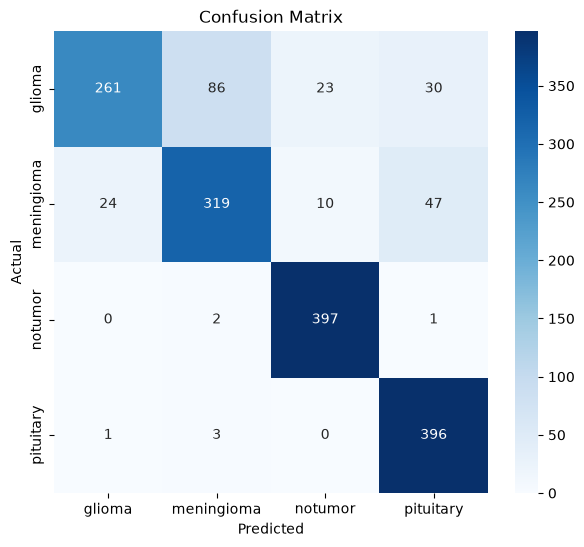

In [31]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=list(test_generator.class_indices.keys()),
    yticklabels=list(test_generator.class_indices.keys())
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

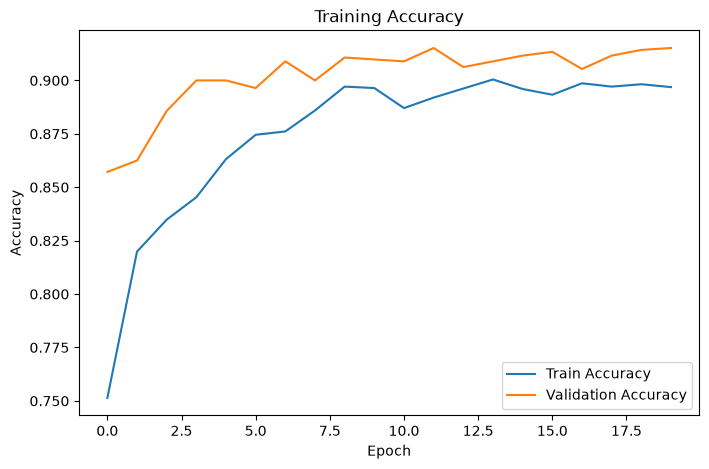

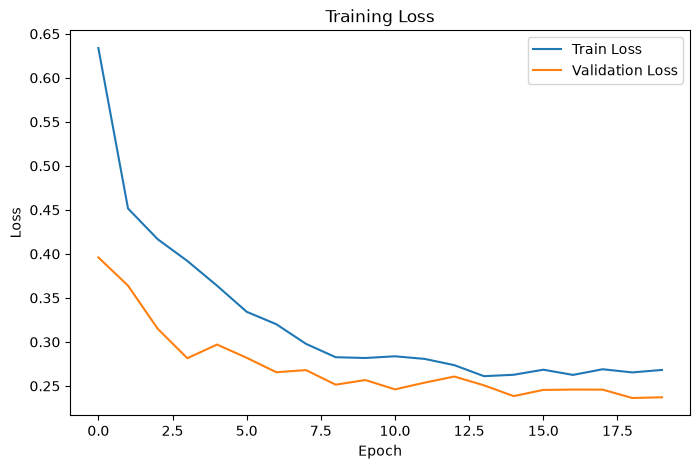

In [33]:
#Combined Accuracy Graph (Both Training Phases)
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend()
plt.show()

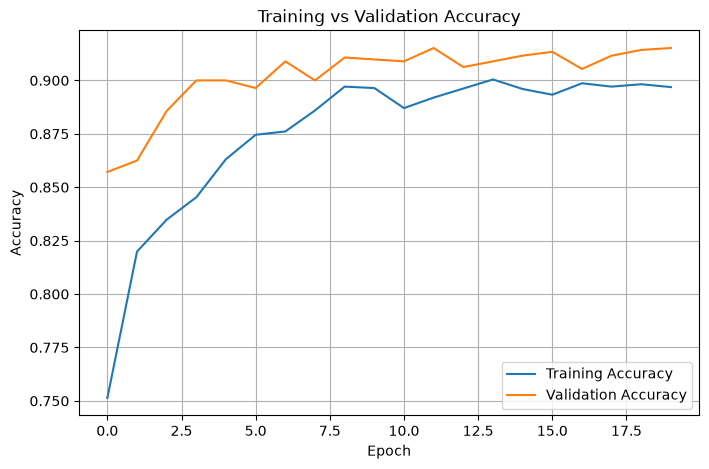

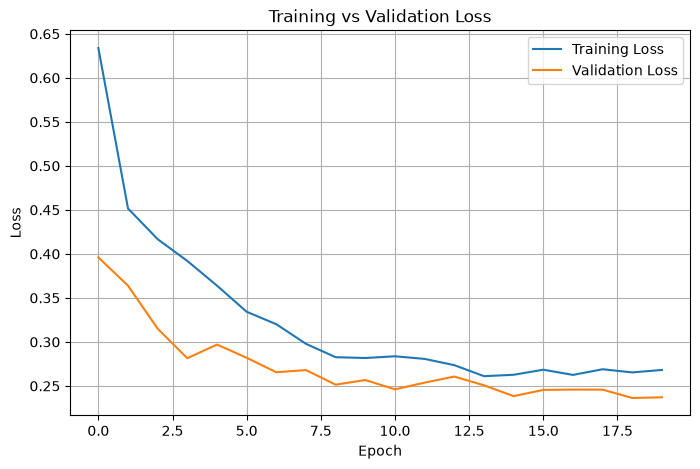

In [38]:
import matplotlib.pyplot as plt

# Accuracy Graph
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Loss Graph
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [39]:
#Save Final Model
best_model.save("../models/final_brain_tumor_model.keras")

print("Final model saved successfully.")

Final model saved successfully.


Found 5600 images belonging to 4 classes.


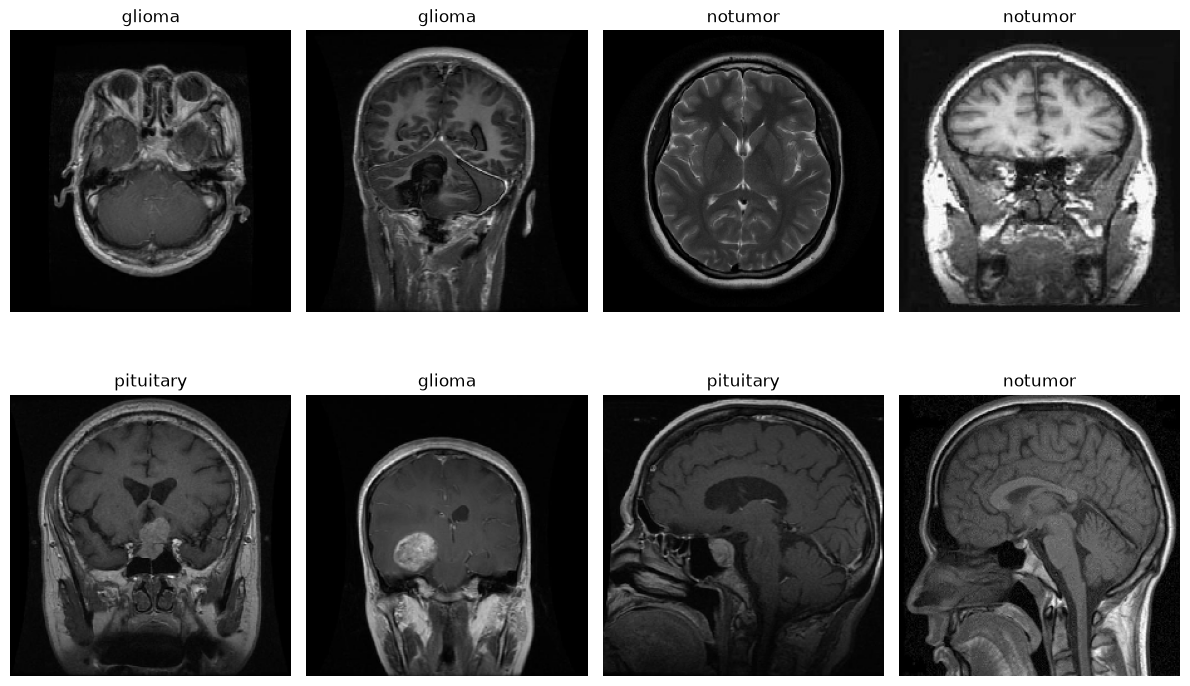

In [37]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np

display_datagen = ImageDataGenerator(rescale=1./255)

display_generator = display_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=8,
    class_mode="categorical",
    shuffle=True
)

images, labels = next(display_generator)

plt.figure(figsize=(12,8))

class_names = list(display_generator.class_indices.keys())

for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(images[i])
    plt.title(class_names[np.argmax(labels[i])])
    plt.axis("off")

plt.tight_layout()
plt.show()